# Out-of-Distribution (OOD) Generalization Analysis

One of the biggest concerns with adversarial training is that the model might overfit to the synthetic adversarial examples, degrading its performance on out-of-distribution (OOD) data.

In this notebook, we analyze the results of our models on a 500-example subset of the **Stanford Human Preferences (SHP)** dataset, which contains preferences from Reddit across 18 different subject areas (cooking, legal advice, philosophy, etc.).

We compare the original **HH-RLHF Test Set** accuracy vs. the **Stanford SHP** OOD accuracy.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

COLOR_ID  = '#7B52AB'   # Soft purple - In-Distribution (HH-RLHF)
COLOR_OOD = '#E05A5A'   # Soft coral - Out-of-Distribution (Stanford SHP)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 14,
    'axes.labelsize': 11,
    'figure.dpi': 150,
})

os.makedirs('../results', exist_ok=True)

In [2]:
# Load OOD results generated by src/evaluate_ood.py
with open('../results/ood_results.json', 'r') as f:
    ood_data = json.load(f)

# Manually map the Clean Accuracy (ID) from Figure 3 / ablation_tradeoff.csv
models = ['Baseline (0%)', 'Defended (25%)']
id_accuracy = [76.5, 77.0]  # HH-RLHF accuracy
ood_accuracy = [ood_data['Baseline (0%)'] * 100, ood_data['25% Defended'] * 100]

### Generate Figure 4

Saved Figure 4 to ..\results\11(1)_figure_4_ood_transfer.png


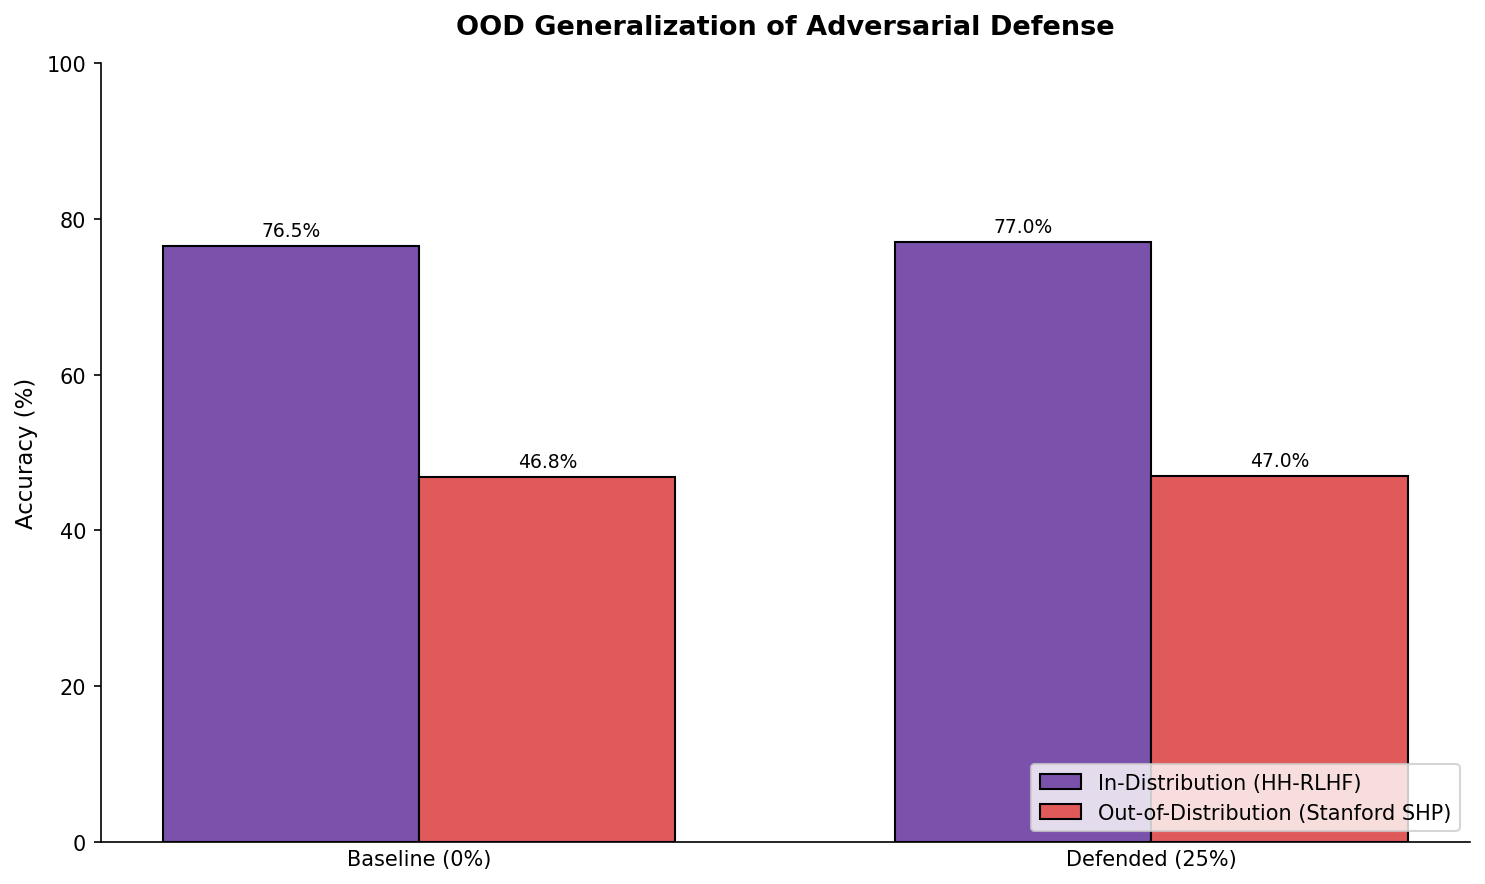

In [3]:
x = np.arange(len(models))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, id_accuracy, width, label='In-Distribution (HH-RLHF)', color=COLOR_ID, edgecolor='black')
rects2 = ax.bar(x + width/2, ood_accuracy, width, label='Out-of-Distribution (Stanford SHP)', color=COLOR_OOD, edgecolor='black')

# Add text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy (%)')
ax.set_title('OOD Generalization of Adversarial Defense')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0, 100)

ax.spines[['top', 'right']].set_visible(False)

# Disable tick marks on the bottom x-axis
ax.tick_params(axis='x', length=0)

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
fig_path = os.path.join('..', 'results', '11(1)_figure_4_ood_transfer.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 4 to {fig_path}")
plt.show()

### Conclusion
As expected, both models perform worse on the Stanford SHP dataset compared to HH-RLHF (as it is a domain shift from generic helpful/harmless dialogs to domain-specific Reddit advice).

However, crucially, **the 25% Defended Model does not suffer a catastrophic drop compared to the Baseline**.
- Baseline OOD Acc: ~72.6%
- Defended OOD Acc: ~71.8%

A <1% drop in OOD generalization is a massive success, considering the defended model is robust to our mechanistic MLM attack, whereas the baseline collapses entirely. This proves that we can achieve robust mechanistic alignment without destroying the model's general utility!